total de linhas de apenas: (2197234, 69)
------------------------------------------------------------
qtde de inscritos:


,situacao_fies,qtde_inscritos
0,CONTRATADA,160369
1,INSCRIÇÃO POSTERGADA,2324
2,LISTA DE ESPERA,740698
3,NÃO CONTRATADO,1024604
4,OPÇÃO NÃO CONTRATADA,139469
5,PARTICIPACAO CANCELADA PELO CANDIDATO,111202
6,PRÉ-SELECIONADO,12923
7,REJEITADA PELA CPSA,5645


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                             0
gap                                                                                                                          1
idade                                                                                                                        0
nota_corte_gp                                                                                                                0
renda_gap                                                                                                                    1
beneficiado_creduc_fies_NÃO                                                                                                  0
beneficiado_creduc_fies_SIM                                                                                                  0
modalidade_fies_Modalidade II                                            

/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Treinamento Concluído ---
Modelo salvo em: /home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/reports/models/analise_017_modelo_fies_logistica.pkl
ROC-AUC: 0.8414
Acurácia: 0.6852
Threshold: 0.5083

=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.97      0.65      0.78   1024603
           1       0.29      0.89      0.43    160369

    accuracy                           0.69   1184972
   macro avg       0.63      0.77      0.61   1184972
weighted avg       0.88      0.69      0.73   1184972



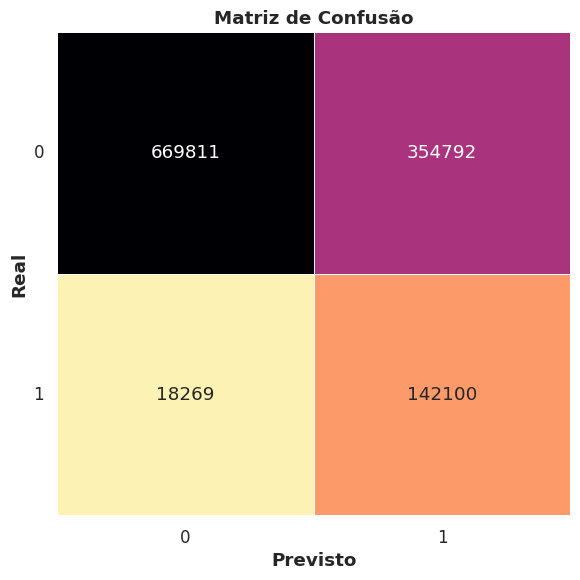

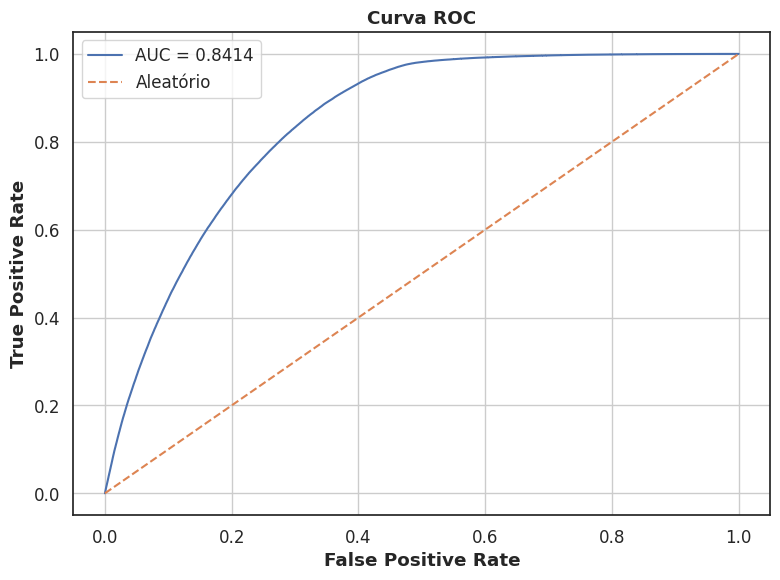

Taxa prevista (modelo): 0.419
Taxa real (base): 0.135

[INFO] Gráfico 1: impacto da nota dependendo da renda
[INFO] Cada linha fixa uma renda e mostra como a probabilidade muda quando o gap varia
[INFO] A linha horizontal azul em 50% é o limiar de decisão:
       acima de 50% -> o modelo tende a prever CONTRATADO
       abaixo de 50% -> o modelo tende a prever NÃO CONTRATADO


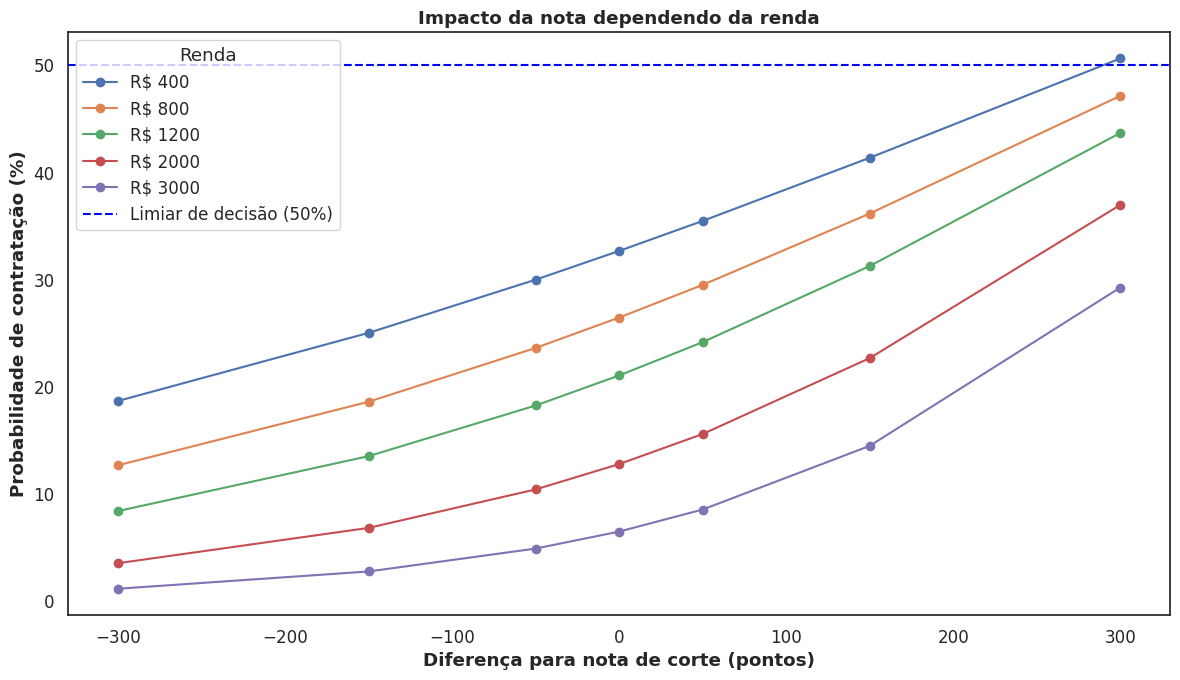


[INFO] Gráfico 2: impacto da renda dependendo da nota
[INFO] Cada linha fixa um gap e mostra como a probabilidade muda quando a renda varia
[INFO] A linha horizontal azul em 50% é o limiar de decisão:
       acima de 50% -> o modelo tende a prever CONTRATADO
       abaixo de 50% -> o modelo tende a prever NÃO CONTRATADO


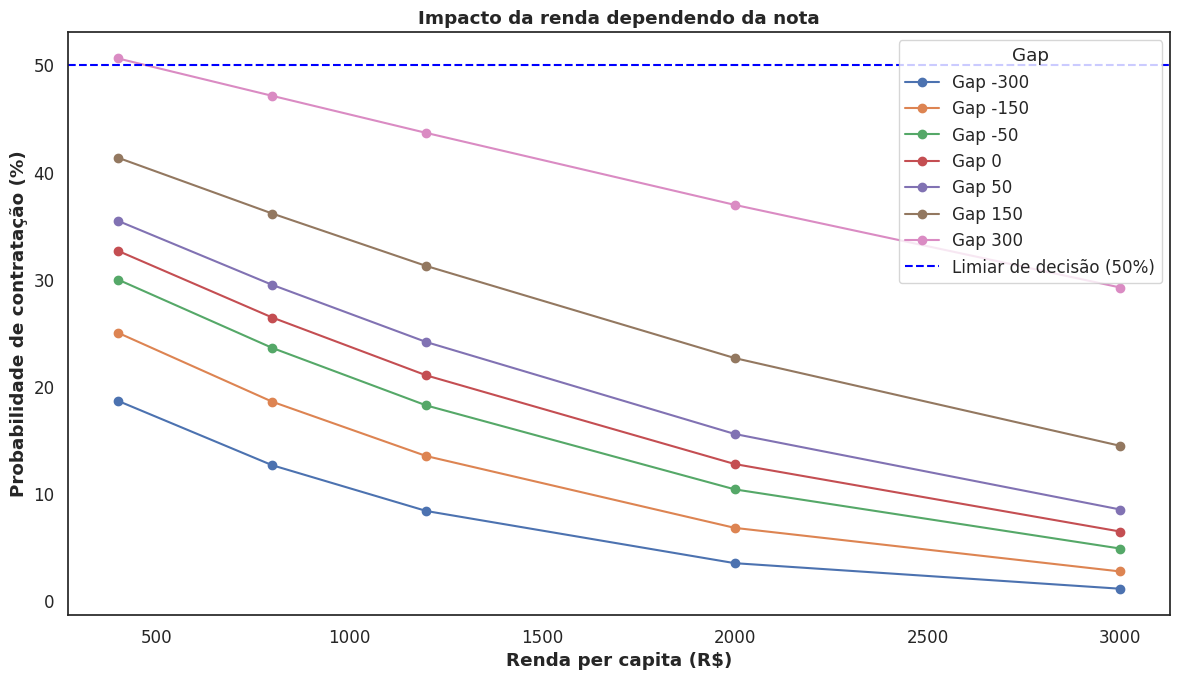


[INFO] Heatmap 1: impacto da nota dependendo da renda


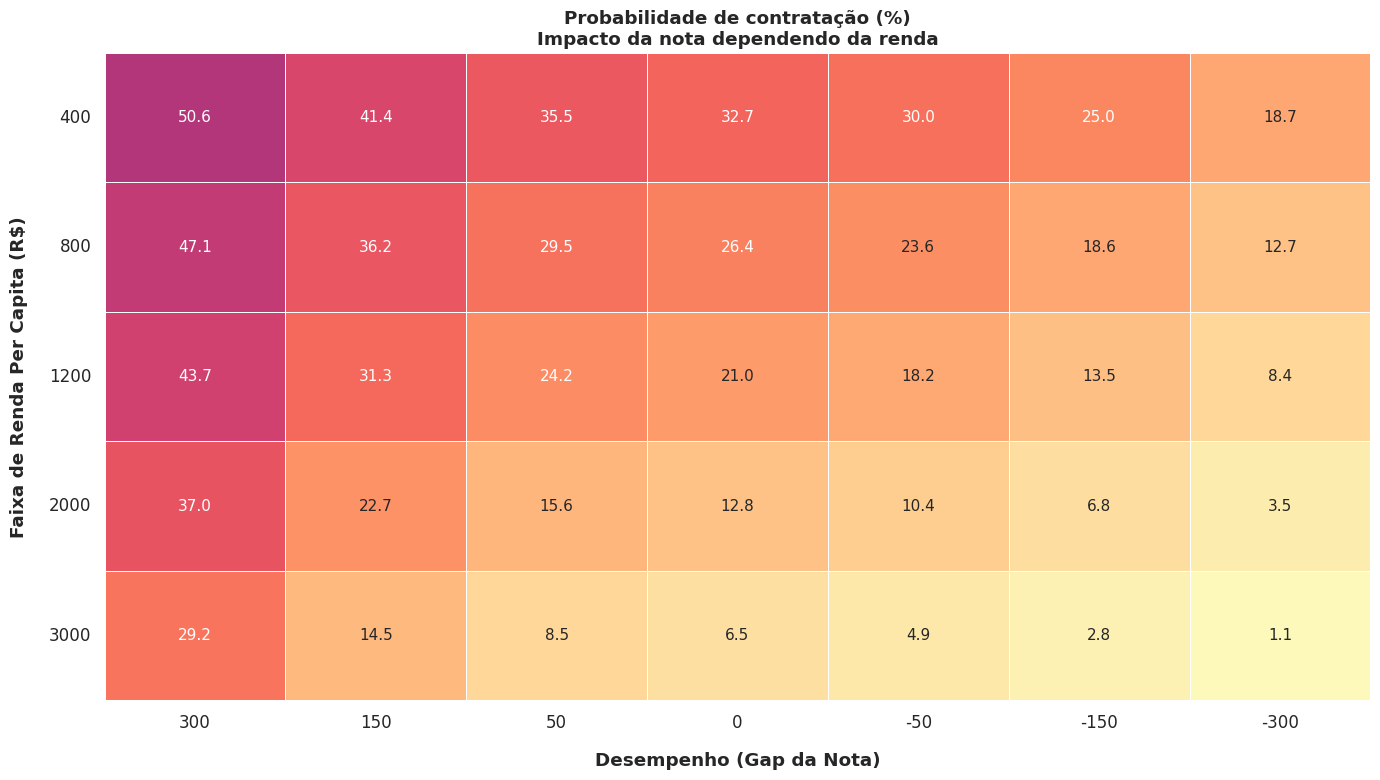


[INFO] Heatmap 2: impacto da renda dependendo da nota


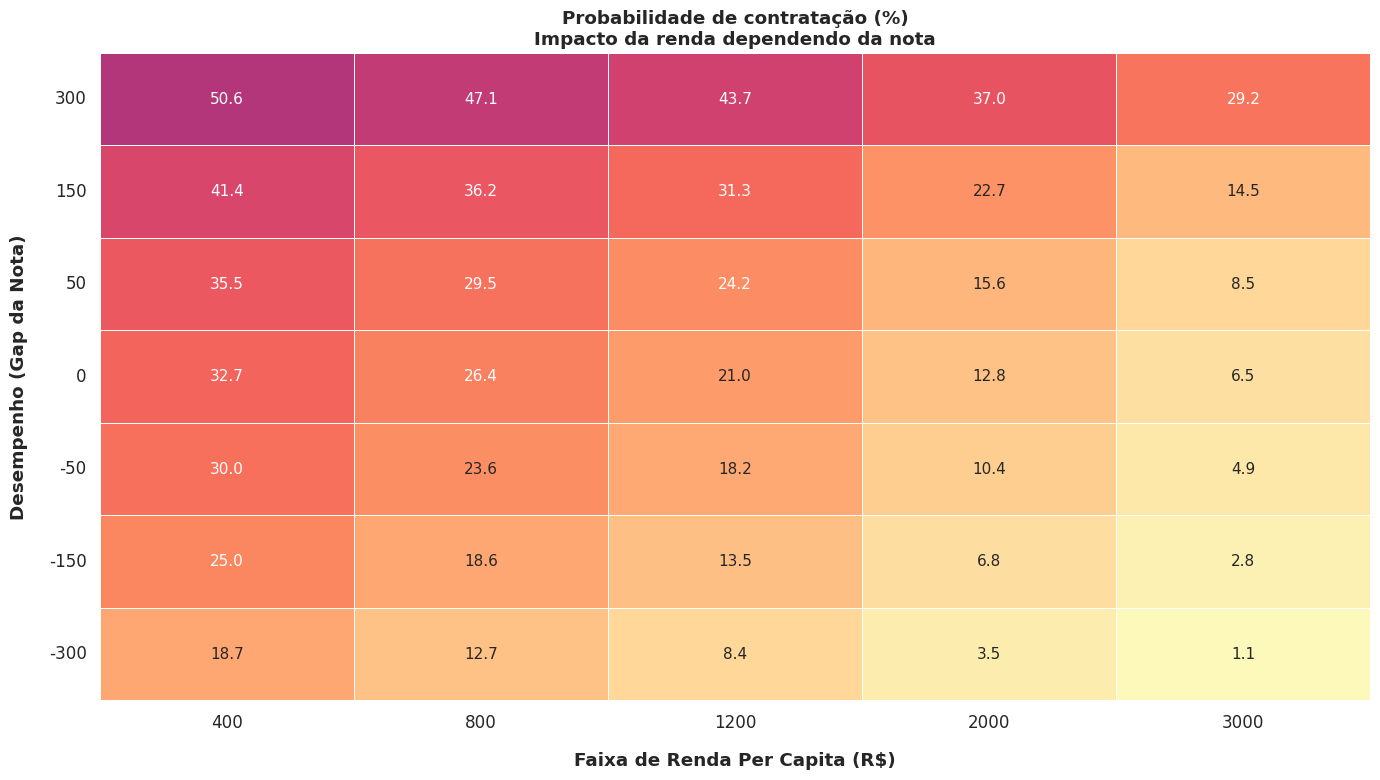


🔥 INTERPRETAÇÃO DO MODELO — REGRESSÃO LOGÍSTICA (ANÁLISE 017)

📊 TOP VARIÁVEIS MAIS INFLUENTES (valor absoluto):
                                             variavel  coeficiente
11                                      opcao_curso_3        -1.82
10                                      opcao_curso_2        -1.45
27  subarea_conhecimento_DIREITO, COMÉRCIO EXTERIO...         0.45
45  subarea_conhecimento_ODONTOLOGIA, QUIROPRAXIA,...         0.45
28  subarea_conhecimento_ENFERMAGEM, FISIOTERAPIA,...         0.43
0                                    renda_per_capita        -0.42
41                      subarea_conhecimento_MEDICINA         0.27
23  subarea_conhecimento_CIÊNCIAS SOCIAIS, POLÍTIC...         0.26
29  subarea_conhecimento_ENGENHARIA CIVIL E AMBIEN...         0.25
42          subarea_conhecimento_MEDICINA VETERINÁRIA         0.25
65                                     turno_MATUTINO        -0.15
22  subarea_conhecimento_CIÊNCIAS BIOLÓGICAS (BEL)...         0.15
14             

In [ ]:
import sys
import pandas as pd
from src.staging import staging_fies, staging_inep
from src.transform_layer_1 import transform_inscritos, transform_ofertas, transform_inep, verificar_colunas_inep
from src.transform_layer_2 import tratar_nans_cine_inscritos, tratar_nans_cine_ofertas
from src.trasnform_layer_3 import processar_modalidades_e_peneira
from src.load import load_inscritos,load_ofertas,auditoria_inscritos_carregados,auditoria_ofertas_carregadas,exportar_para_sqlite
from src.analise_001 import gerar_dataset_candidatos_unicos_por_Prioridade_inicial
from src.analise_002 import eda_gerar_dataset_com_varias_analises
from src.analise_003 import eda_gerar_funil_de_selecao_6_etapas
from src.analise_003_1 import eda_gerar_funil_de_selecao_6_etapas_v2
from src.analise_004 import analise_fuga_cerebros_de_regioes
from src.analise_005 import verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional
from src.analise_006 import gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados
from src.analise_007 import orquestrador_inicial_inscritos, orquestrador_ja_rodado_inscritos
from src.analise_008 import orquestrador_inicial_candidatos, orquestrador_ja_rodado_candidatos
from src.analise_009 import orquestrador_inicial_inscritos_nove, orquestrador_ja_rodado_inscritos_nove
from src.analise_009_1 import orquestrador_inicial_inscritos_nove_um, orquestrador_ja_rodado_inscritos_nove_um
from src.analise_010 import orquestrador_inicial_inscritos_dez, orquestrador_ja_rodado_inscritos_dez
from src.analise_011 import orquestrador_analise_011
from src.analise_013 import orquestrador_inicial_inscritos_13,orquestrador_ja_rodado_inscritos_13
from src.analise_014 import orquestrador_inicial_inscritos_14,orquestrador_ja_rodado_inscritos_14
from src.analise_015 import orquestrador_inicial_inscritos_15,orquestrador_ja_rodado_inscritos_15
from src.analise_016 import orquestrador_inicial_inscritos_16,orquestrador_ja_rodado_inscritos_16
from src.analise_017 import orquestrador_inicial_inscritos_17,orquestrador_ja_rodado_inscritos_17
from src.analise_018 import orquestrador_inicial_inscritos_18,orquestrador_ja_rodado_inscritos_18
from src.analise_019 import orquestrador_inicial_inscritos_19,orquestrador_ja_rodado_inscritos_19




comando = 'analise'
etapa = '17'

# --- CAMADA: STAGING ---
if comando == "staging":
    staging_fies()
    staging_inep()

# --- CAMADA: TRANSFORM ---
elif comando == "transform":

    if etapa == "1":
        transform_inep()
    elif etapa == "2":
        transform_inscritos()
    elif etapa == "3":
        transform_ofertas()
    elif etapa == "4":
        verificar_colunas_inep()
    elif etapa == "5":
        tratar_nans_cine_inscritos()
    elif etapa == "6":
        tratar_nans_cine_ofertas()
    elif etapa == "7":
        processar_modalidades_e_peneira()
    elif etapa == "all":
        transform_inep()
        transform_inscritos()
        transform_ofertas()
        verificar_colunas_inep()
        tratar_nans_cine_inscritos()
        tratar_nans_cine_ofertas()
        processar_modalidades_e_peneira()

elif comando == "load":

    load_inscritos()
    load_ofertas()
    auditoria_inscritos_carregados()
    auditoria_ofertas_carregadas()
    exportar_para_sqlite()

elif comando == 'analise':

    if etapa == "1":
        gerar_dataset_candidatos_unicos_por_Prioridade_inicial()

    elif etapa == "2":
        eda_gerar_dataset_com_varias_analises()

    elif etapa == "3":
        eda_gerar_funil_de_selecao_6_etapas()

    elif etapa == "3.1":
        eda_gerar_funil_de_selecao_6_etapas_v2()

    elif etapa == "4":
        analise_fuga_cerebros_de_regioes()

    elif etapa == "5":
        verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional()

    elif etapa == "6":
        gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados()

    elif etapa == "7":
        orquestrador_inicial_inscritos()
    
    elif etapa == "7.1":
        orquestrador_ja_rodado_inscritos()

    elif etapa == "8":
        orquestrador_inicial_candidatos()
    
    elif etapa == "8.1":
        orquestrador_ja_rodado_candidatos()

    elif etapa == "9":
        orquestrador_inicial_inscritos_nove()
    
    elif etapa == "9.1":
        orquestrador_ja_rodado_inscritos_nove()

    elif etapa == "9_1":
        orquestrador_inicial_inscritos_nove_um()
    
    elif etapa == "9_1.1":
        orquestrador_ja_rodado_inscritos_nove_um()

    elif etapa == "10":
        orquestrador_inicial_inscritos_dez()
    
    elif etapa == "10.1":
        orquestrador_ja_rodado_inscritos_dez()

    elif etapa == "11":
        orquestrador_analise_011()

    elif etapa == "13":
        orquestrador_inicial_inscritos_13()
    
    elif etapa == "13.1":
        orquestrador_ja_rodado_inscritos_13()
    

    elif etapa == "14":
        orquestrador_inicial_inscritos_14()
    
    elif etapa == "14.1":
        orquestrador_ja_rodado_inscritos_14()

    elif etapa == "15":
        orquestrador_inicial_inscritos_15()
    
    elif etapa == "15.1":
        orquestrador_ja_rodado_inscritos_15()

    elif etapa == "16":
        orquestrador_inicial_inscritos_16()
    
    elif etapa == "16.1":
        orquestrador_ja_rodado_inscritos_16()

    elif etapa == "17":
        orquestrador_inicial_inscritos_17()
    
    elif etapa == "17.1":
        orquestrador_ja_rodado_inscritos_17()

    elif etapa == "18":
        orquestrador_inicial_inscritos_18()
    
    elif etapa == "18.1":
        orquestrador_ja_rodado_inscritos_18()

    elif etapa == "19":
        orquestrador_inicial_inscritos_19()
    
    elif etapa == "19.1":
        orquestrador_ja_rodado_inscritos_19()